# 04 — XGBoost Tuning with MLflow Tracking

Replace the logistic regression baseline with XGBoost.
Tune hyperparameters with Optuna, log every trial to MLflow,
then explain the best model with SHAP.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

import xgboost as xgb
import optuna
import mlflow
import mlflow.xgboost
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
)

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
TEST_SIZE    = 0.2
N_TRIALS     = 30
CV_FOLDS     = 3
MODELS_PATH  = Path('../outputs/models')
MODELS_PATH.mkdir(exist_ok=True)

## 1. Load & prep

In [4]:
df = pd.read_csv('../data/raw/creditcard.csv')
df['log_amount']  = np.log1p(df['Amount'])
df['hour_of_day'] = (df['Time'] // 3600) % 24
df = df.drop(columns=['Time', 'Amount'])

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# XGBoost handles scale internally but we keep the ratio for scale_pos_weight
neg, pos        = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.1f}  ({neg:,} legit / {pos} fraud in train)")

scale_pos_weight = 577.3  (227,451 legit / 394 fraud in train)


## 2. XGBoost baseline (no tuning)

Establish the out-of-the-box score before Optuna touches anything.

In [6]:
base_xgb = xgb.XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    use_label_encoder=False,
)
base_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

base_prob  = base_xgb.predict_proba(X_test)[:, 1]
base_prauc = average_precision_score(y_test, base_prob)
print(f"Baseline XGBoost PR-AUC : {base_prauc:.4f}")

Baseline XGBoost PR-AUC : 0.8823


## 3. Hyperparameter tuning with Optuna + MLflow

Each Optuna trial is logged as a child run under the parent MLflow experiment.
CV is stratified so every fold sees representative fraud counts.

In [8]:
mlflow.set_experiment('fraud-xgboost-tuning')

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 20),
        'gamma'             : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'scale_pos_weight'  : scale_pos_weight,
        'eval_metric'       : 'aucpr',
        'random_state'      : RANDOM_STATE,
        'use_label_encoder' : False,
    }

    fold_scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        Xf_tr, Xf_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        yf_tr, yf_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        m = xgb.XGBClassifier(**params)
        m.fit(Xf_tr, yf_tr, verbose=False)
        fold_scores.append(average_precision_score(yf_val, m.predict_proba(Xf_val)[:, 1]))

    mean_prauc = float(np.mean(fold_scores))

    with mlflow.start_run(nested=True):
        mlflow.log_params(params)
        mlflow.log_metric('cv_pr_auc', mean_prauc)

    return mean_prauc


with mlflow.start_run(run_name='optuna-parent'):
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    mlflow.log_metric('best_cv_pr_auc', study.best_value)
    mlflow.log_params(study.best_params)

print(f"\nBest CV PR-AUC : {study.best_value:.4f}")
print(f"Best params    : {study.best_params}")

2026/04/20 12:47:05 INFO mlflow.tracking.fluent: Experiment with name 'fraud-xgboost-tuning' does not exist. Creating a new experiment.


  0%|          | 0/30 [00:00<?, ?it/s]


Best CV PR-AUC : 0.8515
Best params    : {'n_estimators': 426, 'max_depth': 6, 'learning_rate': 0.07735538624231407, 'subsample': 0.6911086245674193, 'colsample_bytree': 0.7532397313826066, 'min_child_weight': 8, 'gamma': 1.2650189107909036, 'reg_alpha': 0.022539587918194208, 'reg_lambda': 0.014466821454484483}


## 4. Retrain best params on full training set

In [10]:
best_params = study.best_params | {
    'scale_pos_weight' : scale_pos_weight,
    'eval_metric'      : 'aucpr',
    'random_state'     : RANDOM_STATE,
    'use_label_encoder': False,
}

best_model = xgb.XGBClassifier(**best_params)
best_model.fit(X_train, y_train, verbose=False)

y_prob  = best_model.predict_proba(X_test)[:, 1]
y_pred  = (y_prob >= 0.5).astype(int)
prauc   = average_precision_score(y_test, y_prob)
rocauc  = roc_auc_score(y_test, y_prob)

print(f"Tuned XGBoost PR-AUC  : {prauc:.4f}  (baseline was {base_prauc:.4f})")
print(f"Tuned XGBoost ROC-AUC : {rocauc:.4f}")

Tuned XGBoost PR-AUC  : 0.8795  (baseline was 0.8823)
Tuned XGBoost ROC-AUC : 0.9816


## 5. Confusion matrix

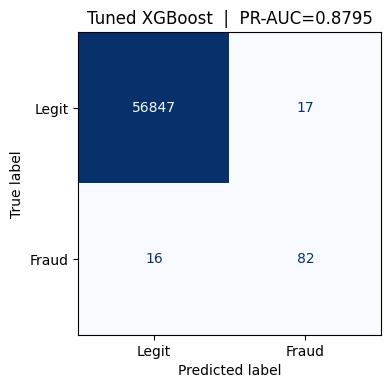

Fraud caught (TP) : 82
Fraud missed (FN) : 16
False alarms (FP) : 17
Correct legit (TN): 56,847


In [12]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Tuned XGBoost  |  PR-AUC={prauc:.4f}')
plt.tight_layout()
plt.savefig('../outputs/figures/04_confusion_matrix.png')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Fraud caught (TP) : {tp:,}")
print(f"Fraud missed (FN) : {fn:,}")
print(f"False alarms (FP) : {fp:,}")
print(f"Correct legit (TN): {tn:,}")

## 6. SHAP explainability

We need to explain WHY XGBoost flags specific transactions as fraud

In [14]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Global feature importance
fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Mean |SHAP| — global feature importance')
plt.tight_layout()
plt.savefig('../outputs/figures/04_shap_importance.png')
plt.show()

ValueError: could not convert string to float: '[5E-1]'

In [ ]:
# Beeswarm — shows direction of each feature's effect
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP beeswarm — feature effect direction')
plt.tight_layout()
plt.savefig('../outputs/figures/04_shap_beeswarm.png')
plt.show()

In [ ]:
# Single transaction waterfall — explain one fraud prediction
fraud_indices = np.where(y_test.values == 1)[0]
idx           = fraud_indices[0]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx],
        feature_names=X_test.columns.tolist(),
    ),
    show=False,
)
plt.title(f'Waterfall — why transaction #{idx} was flagged as fraud')
plt.tight_layout()
plt.savefig('../outputs/figures/04_shap_waterfall.png')
plt.show()

## 7. Save model and log final run to MLflow

In [ ]:
joblib.dump(best_model, MODELS_PATH / 'xgboost_tuned.pkl')
print(f"Saved: models/xgboost_tuned.pkl")

with mlflow.start_run(run_name='final-xgboost'):
    mlflow.log_params(best_params)
    mlflow.log_metrics({
        'test_pr_auc' : prauc,
        'test_roc_auc': rocauc,
        'precision'   : precision_score(y_test, y_pred),
        'recall'      : recall_score(y_test, y_pred),
        'f1'          : f1_score(y_test, y_pred),
    })
    mlflow.xgboost.log_model(best_model, artifact_path='model')

print(f"\nNext: notebook 05 - full evaluation and threshold selection")
print(f"Target: beat PR-AUC of {prauc:.4f}")